In [46]:
import sys
print(sys.executable)


/usr/local/bin/python3


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from knn import KNN

In [48]:
iris = load_iris()
x, y = iris.data, iris.target
df = pd.DataFrame(x, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in y] #add species column
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Figure size 1200x600 with 0 Axes>

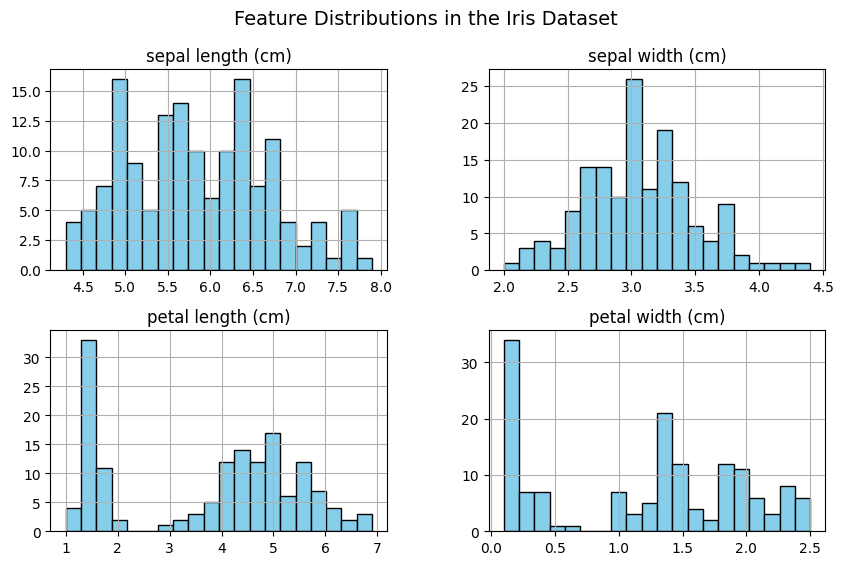

In [49]:
#Visualizing Feature Distributions

plt.figure(figsize=(12,6))
df.drop(columns=['species']).hist(bins=20, figsize=(10,6), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions in the Iris Dataset", fontsize=14)
plt.show()

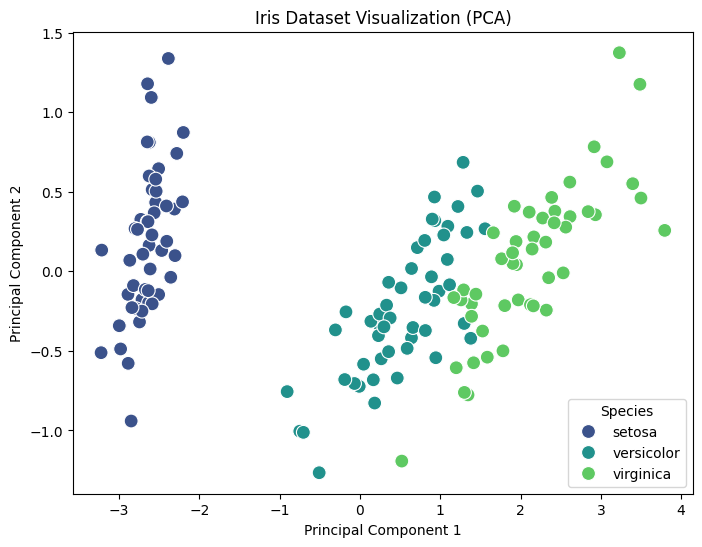

In [50]:
#Scatter Plot Using PCA (Dimensionality Reduction)
#Reduces data to 2D using PCA and plots it 

pca = PCA(n_components=2) #reduce dimensions to 2
x_pca = pca.fit_transform(x) #Apply PCA

# Convert numerical labels (0,1,2) into species names
labels = [iris.target_names[i] for i in y]
# Scatter plot with PCA components 
plt.figure(figsize=(8,6))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:, 1], hue=labels, palette="viridis", s=100)
plt.title("Iris Dataset Visualization (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Species")
plt.show()


In [51]:
#Train the Custom KNN Model
#Splits data, trains KNN, and evaluates accuracy

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
knn = KNN(k=3)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


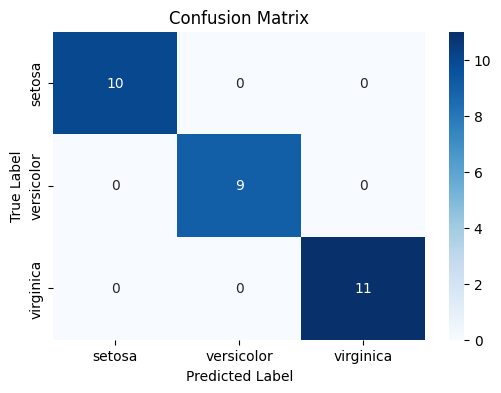

In [52]:
#Confusion Matrix
#A confusion matrix helps analyze where the model made wrong predictions.

from sklearn.metrics import confusion_matrix
import seaborn as sns

#Compute confusion matrix 
cm = confusion_matrix(y_test, y_pred)
#plot confusion matrix
plt.figure(figsize=(6, 4))
# visualizes the confusion matrix for clarity.
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()